# Introduction to Mathematical Modelling

**by Dr Kamil Erguler**  
Climate and One Health Group  
CARE-C - The Cyprus Institute

---

[Previous (Dungeons & Dragons)](https://veclim.com/tutorials-viewer/localfile/MathMod/T01_IMM_D&D.ipynb) --- [Next (Regression)](https://veclim.com/tutorials-viewer/localfile/MathMod/T03_IMM_regression.ipynb)

So, our DM swears that she has not been lying about the outcomes of the die, and that she has been using the 20-sided die all along. There must be a problem with the die itself.

All right, you say. Let's examine the chances of that.

Suppose we introduce another model, `d20.unfair`, in which the side probabilities are not all equal to `1/20`, but are instead given by

$
\mathbf{p} = (p_1, p_2, \ldots, p_{20}),
$

where

$
\sum_{i=1}^{20} p_i = 1.
$

The likelihood of observing a particular outcome, say `1`, is then

$
P(x = 1 \mid \mathbf{p}) = p_1.
$

At the beginning, we have no reason to favour any side over another. Let's say we trust that the DM might be telling the truth. We may then use a uniform prior over the possible values of $\mathbf{p}$. Under this prior, the posterior density of the side probabilities becomes proportional to the likelihood:

$
P(\mathbf{p} \mid x) \propto P(x \mid \mathbf{p}).
$

The likelihood of observing a set of rolls then becomes proportional to

$
P(x \mid \mathbf{p})
\propto p_1^{n_1}p_2^{n_2}\ldots p_{20}^{n_{20}},
$

where $n_1, n_2, \ldots, n_{20}$ represent the number of times each side is observed.

This has the same form as the unnormalised <a href="https://www.statlect.com/probability-distributions/Dirichlet-distribution" target="_blank" rel="noopener noreferrer">Dirichlet distribution</a>, with one added to the number of times each side is observed:

$
p_1^{n_1}p_2^{n_2}\ldots p_{20}^{n_{20}} \propto \mathrm{Dirichlet}(\mathbf{p} \mid n_1+1,n_2+1,\ldots,n_{20}+1).
$

The two-parameter version is equivalent to the <a href="https://www.statlect.com/probability-distributions/beta-distribution" target="_blank" rel="noopener noreferrer">beta distribution</a>,

$
p_1^{n_1}p_2^{n_2} \propto \mathrm{Dirichlet}(\mathbf{p} \mid n_1+1,n_2+1),
$

which is equivalent to

$
P(p_1 \mid x) =
\mathrm{Beta}(p_1 \mid n_1+1,n_2+1),
$

with

$
p_2 = 1-p_1.
$

Including the normalising constant, the posterior density for the side probabilities of the 20-sided die can be written as

$
P(\mathbf{p} \mid x) =
\mathrm{Dirichlet}(\mathbf{p} \mid n_1+1,n_2+1,\ldots,n_{20}+1).
$

If we continue rolling the die, and the next outcome is `1`, then the posterior above becomes the new prior. The new observation adds one more count to side `1`, so the updated posterior density becomes

$
P(\mathbf{p} \mid \{x,1\}) =
\mathrm{Dirichlet}(\mathbf{p} \mid n_1+2,n_2+1,\ldots,n_{20}+1).
$


## Wait! Why do we need this Dirichlet density for a uniform prior?

Here, the roll outcomes accumulate information about a single set of side probabilities, $\mathbf{p}$. As more rolls are observed, we learn more about each side probability.

This is different from deciding which die was chosen. In the earlier model-selection problem, the DM had chosen one die: `d4`, `d6`, or `d20`. Each roll gave us information about which one of these three fixed models was more plausible.

Had she chosen a new die at each roll, then we would need to learn about the frequency with which each die was being chosen. In that case, a secondary prior over those frequencies might have been appropriate. But that was not the case. Only one die was chosen.


## Let's inspect the Dirichlet densities

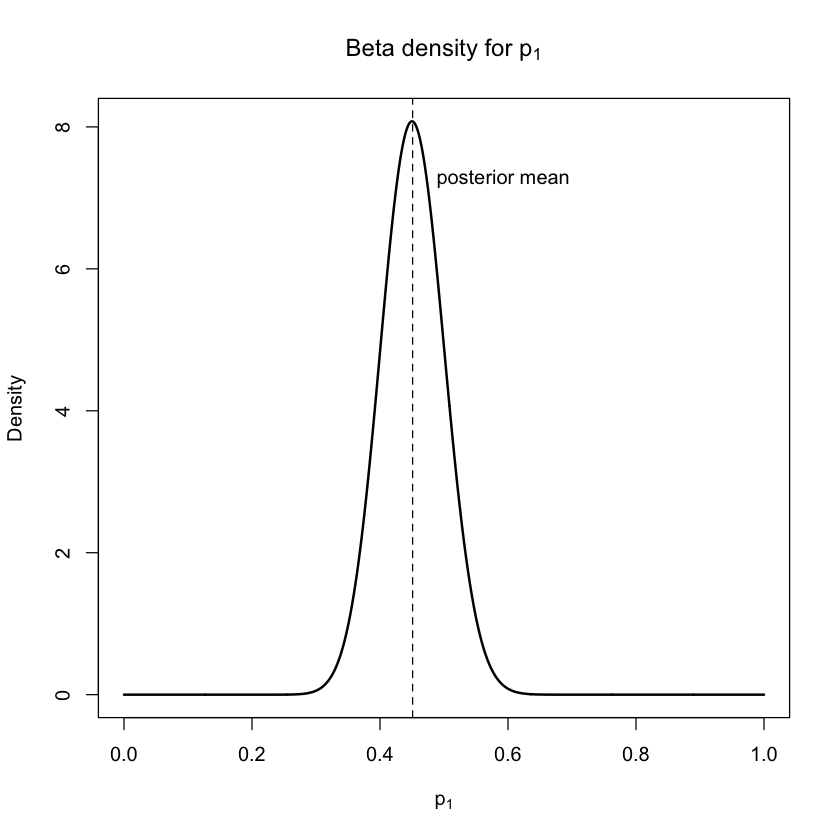

In [1]:
## -----------------------------
## 1. Beta density for p1
## -----------------------------

# Let's say we observed one side of a coin 45 times and the other side 55 times. 
# What is the posterior distribution of the probability of observing the first side?
n1 <- 45
n2 <- 55

alpha1 <- n1 + 1
alpha2 <- n2 + 1

p1 <- seq(0, 1, length.out = 1000)

beta_density <- function(p1, alpha1, alpha2) {
  return( p1^(alpha1 - 1) * (1 - p1)^(alpha2 - 1) * gamma(alpha1 + alpha2) / (gamma(alpha1) * gamma(alpha2)) )
}

density_p1 <- beta_density(p1, alpha1, alpha2)
# or 
# density_p1 <- dbeta(p1, alpha1, alpha2)

par(bg = "white")

plot(p1, density_p1, type = "l", lwd = 2, xlab = expression(p[1]), ylab = "Density", main = expression(paste("Beta density for ", p[1])))

abline(v = alpha1 / (alpha1 + alpha2), lty = 2)

text(x = alpha1 / (alpha1 + alpha2), y = max(density_p1) * 0.9, labels = "posterior mean", pos = 4, offset = 1.0)

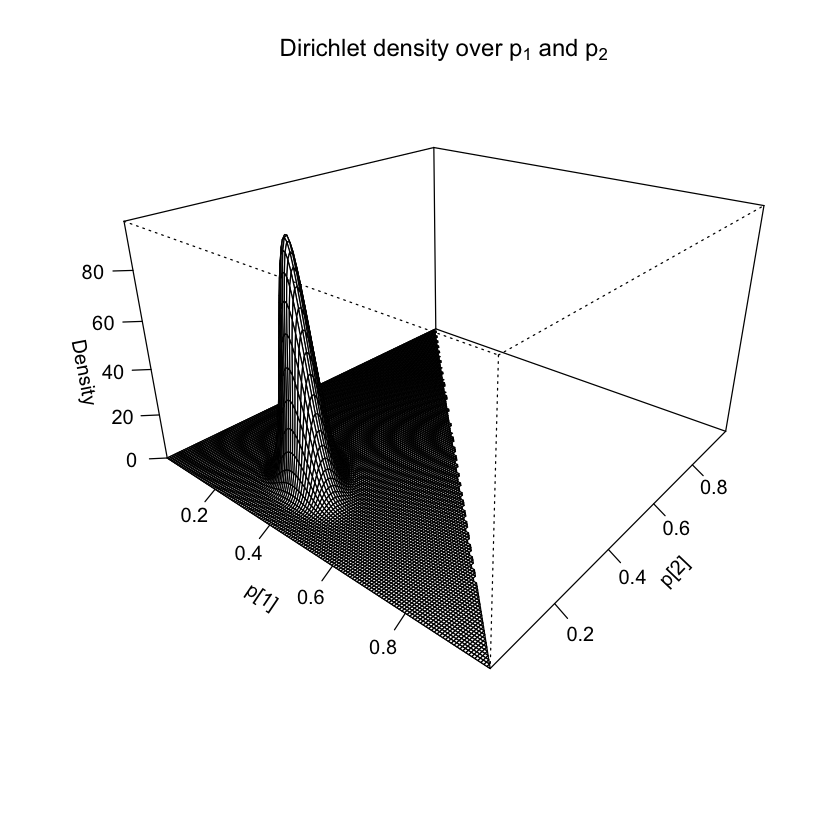

In [2]:
## -----------------------------
## 2. Dirichlet density over p1 and p2
## -----------------------------

# Let's say we observed three categories with counts 34, 16, and 50. 
# What is the posterior distribution over the probabilities of these categories?
n1 <- 34
n2 <- 16
n3 <- 50

alpha <- c(n1 + 1, n2 + 1, n3 + 1)

dirichlet_density <- function(p, alpha) {
  return( prod(p^(alpha - 1)) * gamma(sum(alpha)) / prod(gamma(alpha)) )
}

grid_size <- 150

p1 <- seq(0.001, 0.999, length.out = grid_size)
p2 <- seq(0.001, 0.999, length.out = grid_size)

z <- matrix(NA, nrow = grid_size, ncol = grid_size)

for (i in seq_along(p1)) {
  for (j in seq_along(p2)) {
    
    p3 <- 1 - p1[i] - p2[j]
    
    if (p3 > 0) {
      z[i, j] <- dirichlet_density(
        p = c(p1[i], p2[j], p3),
        alpha = alpha
      )
    }
  }
}

par(bg = "white")

persp(x = p1, y = p2, z = z, theta = 40, phi = 25, expand = 0.6, ticktype = "detailed", 
      xlab = expression(p[1]), ylab = expression(p[2]), zlab = "Density",
      main = expression(paste("Dirichlet density over ", p[1], " and ", p[2])))


## Models can have their own parameters

There is one more important point before we add `d20.unfair` to our model list.

The models we used so far had no unknown parameters. For example, under the fair `d20` model, the probability of each side is fixed at `1/20`. Once the model is chosen, everything else is already known.

The `d20.unfair` model is different. It does not specify one fixed set of side probabilities. Instead, it allows many possible versions of the die:

$
\mathbf{p} = (p_1,p_2,\ldots,p_{20}).
$

So, when we ask how likely a new observation is under `d20.unfair`, we are not asking for the probability under one particular value of $\mathbf{p}$. We are asking for the probability of the observation after considering all possible values of $\mathbf{p}$, weighted by how plausible they are under the model.

Then, for the `d20.unfair` model $M$ with unknown parameters $\mathbf{p}$, the probability of the data, $x$, under the model is therefore

$
P(x \mid M) = \int_{\Delta}
P(x \mid \mathbf{p}, M)
P(\mathbf{p} \mid M)
\,d\mathbf{p}.
$

Here, $\Delta$ represents the space of all possible values of $\mathbf{p}$. Since $\mathbf{p}$ contains probabilities, not every combination of values is allowed: each value must be non-negative, and all values must add up to one.

In words, we calculate the probability of the data for each possible parameter value, then average over all parameter values allowed by the model.


## Integrating the unfair 20-sided die model

For the unfair die model, $M =$ `d20.unfair`, the probability of the data under the model is calculated by averaging over all possible values of the side probabilities:

$
P(x \mid M) = \int_{\Delta}
P(x \mid \mathbf{p}, M)
P(\mathbf{p} \mid M)
\,d\mathbf{p}.
$

For a single new observation, side $k$, this becomes the average value of $p_k$ under the Dirichlet distribution:

$
P(x = k \mid M) =
\int_{\Delta} p_k \,
\mathrm{Dirichlet}(\mathbf{p} \mid \alpha_1,\alpha_2,\ldots,\alpha_{20})
\,d\mathbf{p},
$

where

$
\alpha_1 = n_1 + 1,
$

$
\alpha_2 = n_2 + 1,
$

$
\ldots
$

$
\alpha_{20} = n_{20} + 1.
$

So, we are averaging $p_k$ over all possible unfair 20-sided dice, weighted by how plausible each one is after the observations seen so far.

For the Dirichlet distribution, this average has a simple form:

$
P(x = k \mid M) =
\mathbb{E}[p_k] =
\frac{\alpha_k}{\sum_{j=1}^{20}\alpha_j}.
$

In words, for this specific case, the probability of observing side $k$ under the `d20.unfair` model can be calculated directly from the observed counts.


## Let's try it!

In [ ]:
model_d20_unfair <- function(alpha0 = rep(1, 20)) {
  # If alpha0 is not provided, we start with equal initial values for all side probabilities
  # (alpha0 = 1, meaning n0 = 0, for each face), so no side is favoured
  # before any rolls are observed.
  #
  # This is a weak starting point: a few observations can tilt the inferred
  # probabilities, but many observations are needed before they become strongly concentrated.
  alpha <- alpha0
  
  function(x, update=TRUE) {
    if (x >= 1 && x <= 20) {
      # Probability of observing x under current belief
      like <- alpha[x] / sum(alpha)
      
      if (update) {
        # Update internal state after observing x
        alpha[x] <<- alpha[x] + 1

      } else {
        # If update is FALSE, we return the likelihood and the internal state (alpha) for inspection
        return(list(
          like = like,
          alpha = alpha
        ))
      }
      return(like)
    } else {
      return(0)
    }
  }
}

# Warning: By default, the function updates itself when called.
#          To inspect the likelihood and the internal state, you should call likelihoods[["d20.unfair"]](x, update=FALSE)

In [35]:
# To assume that all models are equally likely a priori
uniform_prior <- function() {
    prior <- c()
    for (m in names(likelihoods)) {
      prior[m] <- 1 / length(likelihoods)
    }
    return(prior)
}

# Updating a prior belief on the basis of an observation
bayesian_update <- function(observation, prior) {
    unnormalised <- c()
    for (model in names(likelihoods)) {
        likelihood <- likelihoods[[model]]
        
        # Probability of the new observation under each model
        like <- likelihood(observation)

        # Unnormalised posterior
        unnormalised[model] <- like * prior[model]
    }

    # Normalise, with probability of observations, so that probabilities add up to 1
    posterior <- unnormalised / sum(unnormalised)

    return(posterior)
}

p.cheat <- 0.25

# Probability of observing x under a die model
likelihoods <- c("d4" = function(x) { return (ifelse(x >= 1 && x <= 4, 1 / 4, 0)) },
                 "d6" = function(x) { return (ifelse(x >= 1 && x <= 6, 1 / 6, 0)) }, 
                 "d20" = function(x) { return (ifelse(x >= 1 && x <= 20, 1 / 20, 0)) },
                 "d4.cheat" = function(x) { return (p.cheat * (1/20) + (1 - p.cheat) * (ifelse(x >= 1 && x <= 4, 1 / 4, 0))) },
                 "d6.cheat" = function(x) { return (p.cheat * (1/20) + (1 - p.cheat) * (ifelse(x >= 1 && x <= 6, 1 / 6, 0))) },
                 "d20.cheat" = function(x) { return (p.cheat * (1/20) + (1 - p.cheat) * (ifelse(x >= 1 && x <= 20, 1 / 20, 0))) },
                 #
                 # Here is the alternative model of an unfair 20-sided die with 20 internal parameters (side biases), 
                 # which are updated after each observation:
                 #
                 "d20.unfair" = model_d20_unfair())

In [36]:
# Observed sequence
observations <- c(1, 3, 3, 2, 1, 3, 2, 4, 10)

model_probabilities <- matrix(
    nrow = length(observations)+1,
    ncol = length(names(likelihoods))
  )
  colnames(model_probabilities) <- names(likelihoods)
  rownames(model_probabilities) <- c("Prior", paste("Data",1:length(observations),":",as.character(observations))
)

current_prior <- uniform_prior()
model_probabilities[1,] <- current_prior
for (m in seq_along(observations)) {
    current_prior <- bayesian_update(observations[m], current_prior)
    model_probabilities[m+1, ] <- current_prior
}

## Before we evaluate posterior probabilities

Before evaluating the posterior model probabilities, let's first examine what the data suggest about the side probabilities of the `d4.unfair` model. As expected, the `alpha` values correspond to an offset version of the histogram of observed side frequencies: each observed count is increased by the initial value assigned to that side in `alpha0`.

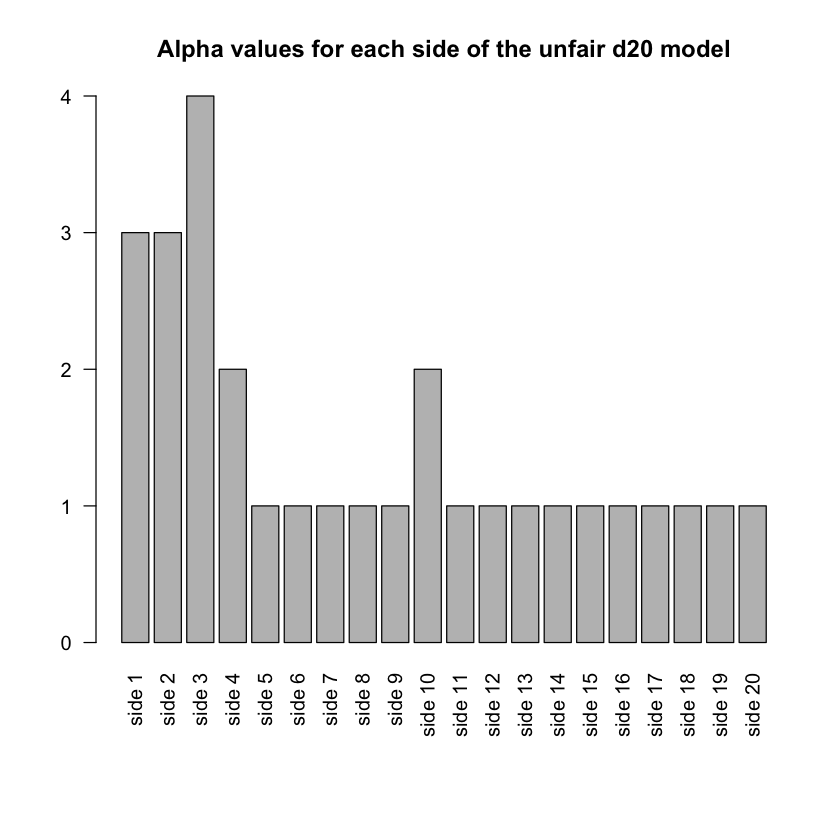

In [43]:
p <- seq(0.0001, 0.5, length.out = 1000)

# Get the current alpha values from the unfair d20 model
alpha <- likelihoods[["d20.unfair"]](1, update = FALSE)$alpha

par(bg = "white", xpd = TRUE, mar = c(8, 4, 4, 2))

barplot(alpha, names.arg = paste0("side ", 1:20), las = 2, main = "Alpha values for each side of the unfair d20 model")

The inferred side probabilities, $\mathbf{p}$, follow a Dirichlet distribution with 20 components. We cannot plot this full space directly, but we can visualise the marginal distribution of each side probability. That is, for each side $k$, we can ask how plausible different values of $p_k$ are, while grouping all other sides together.

For a Dirichlet distribution,

$
\mathbf{p} \sim \mathrm{Dirichlet}(\alpha_1,\alpha_2,\ldots,\alpha_{20}),
$

the marginal distribution of $p_k$ is

$
P(p_k \mid x) = \mathrm{Beta}\left(
p_k \mid
\alpha_k,
\sum_{j \neq k}\alpha_j
\right).
$

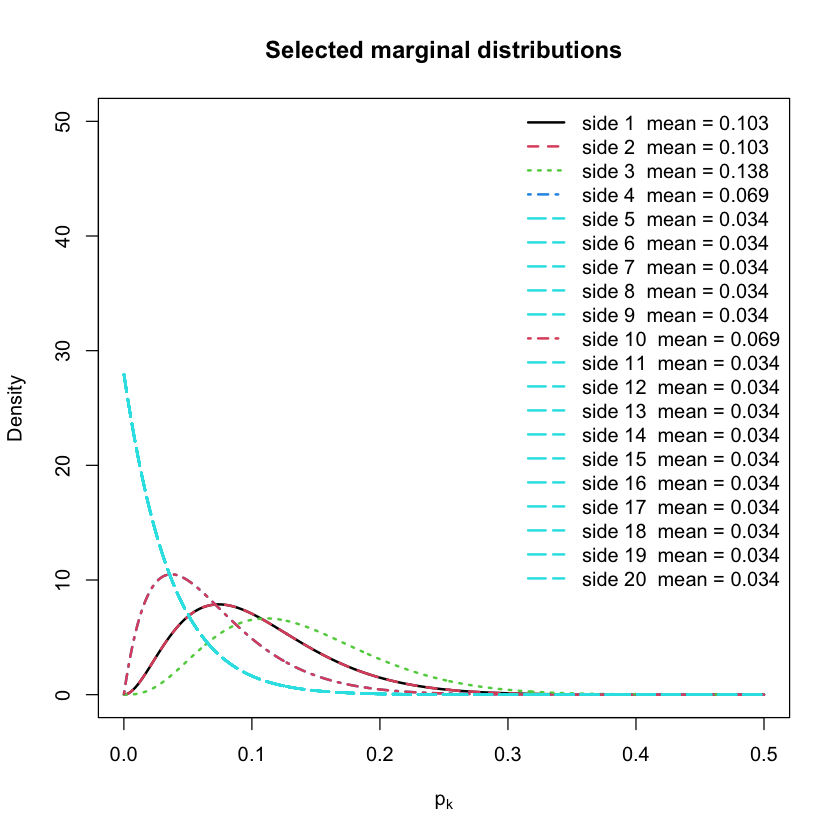

In [44]:
mat <- matrix(
  nrow = length(p),
  ncol = 20
)

colnames(mat) <- paste0("side ", 1:20)

for (k in 1:20) {
  mat[, k] <- dbeta(p, alpha[k], sum(alpha) - alpha[k])
}

# Posterior mean for each selected side
posterior_mean <- alpha / sum(alpha)

# Colours and line types
mask <- posterior_mean == min(posterior_mean)
cols <- 1:20
cols[mask] <- cols[mask][1]
ltys <- 1:20
ltys[mask] <- ltys[mask][1]

par(bg = "white", xpd = TRUE)

matplot(p, mat, type = "l", lwd = 2, lty = ltys, col = cols, ylim = c(0, 50),
        xlab = expression(p[k]), ylab = "Density", main = "Selected marginal distributions")

legend("topright", legend = paste0(colnames(mat), "  mean = ", round(posterior_mean, 3)),
       lty = ltys, lwd = 2, col = cols, bty = "n")

As the plot shows, the data do not yet contain much information about the individual side probabilities. We would need to observe many more outcomes before we could estimate all 20 side probabilities with confidence.

How many more? That depends on how precise we want the estimates to be. In the Dirichlet model, uncertainty decreases as the total count

$
\alpha_0 = \sum_{j=1}^{20}\alpha_j
$

increases. The posterior variance of each side probability is

$
\mathrm{Var}(p_k \mid x) = \frac{
\alpha_k(\alpha_0-\alpha_k)
}{
\alpha_0^2(\alpha_0+1)
}.
$

So there is no single universal number of rolls. The required amount of data depends on the desired precision, the number of sides, and how uneven the true side probabilities are.

Now, let's see which model has the highest probability given the data.

                  d4       d6      d20 d4.cheat d6.cheat d20.cheat d20.unfair
Prior       0.142857 0.142857 0.142857 0.142857 0.142857  0.142857   0.142857
Data 1 : 1  0.276498 0.184332 0.055300 0.221198 0.152074  0.055300   0.055300
Data 2 : 3  0.399195 0.177420 0.015968 0.255485 0.120757  0.015968   0.015207
Data 3 : 3  0.498872 0.147814 0.003991 0.255422 0.083000  0.003991   0.006911
Data 4 : 2  0.586770 0.115905 0.000939 0.240341 0.053693  0.000939   0.001414
Data 5 : 1  0.661753 0.087144 0.000212 0.216843 0.033305  0.000212   0.000531
Data 6 : 3  0.725621 0.063703 0.000046 0.190217 0.020086  0.000046   0.000280
Data 7 : 2  0.779052 0.045596 0.000010 0.163379 0.011861  0.000010   0.000092
Data 8 : 4  0.822919 0.032109 0.000002 0.138063 0.006891  0.000002   0.000014
Data 9 : 10 0.000000 0.000000 0.000058 0.952081 0.047518  0.000058   0.000285


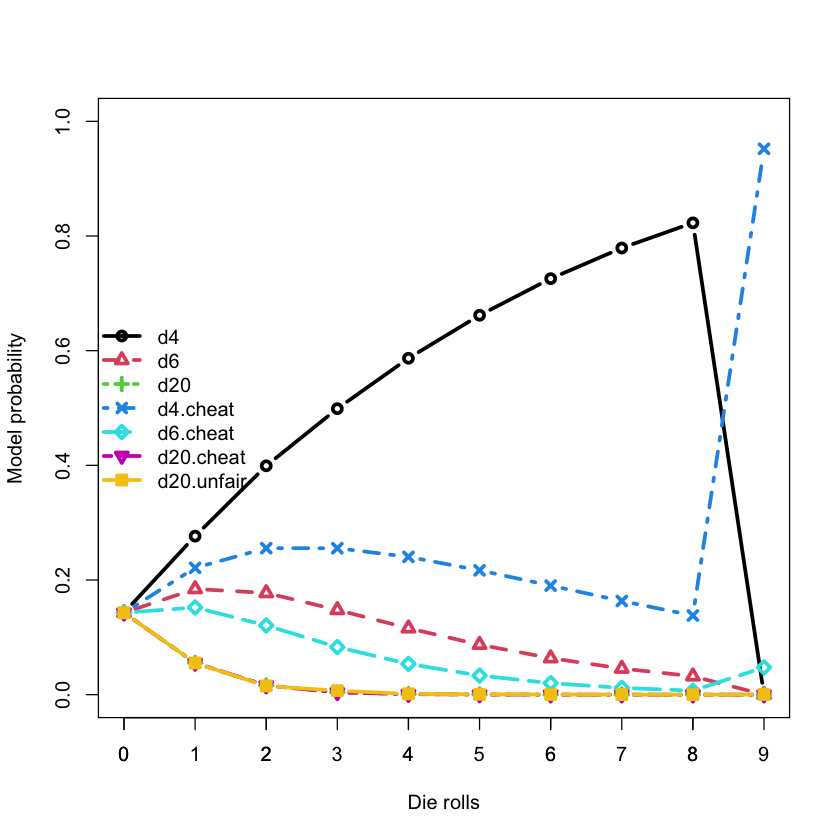

In [45]:
print(round(model_probabilities, 6))

steps <- 0:(nrow(model_probabilities) - 1)

par(bg = "white")

cols <- seq_len(ncol(model_probabilities))
pchs <- seq_len(ncol(model_probabilities))
ltys <- seq_len(ncol(model_probabilities))

matplot(steps, model_probabilities, 
        type = "b", lw = 3, pch = pchs, lty = ltys, col = cols, ylim = c(0, 1), 
        xlab = "Die rolls", ylab = "Model probability")

axis(side = 1, at = steps)

legend("left", legend = colnames(model_probabilities), lw = 3, lty = ltys, pch = pchs, col = cols, bty = "n")

So, with over 95% posterior probability, the 4-sided die was chosen and the DM had been occasionally lying to us about the outcomes. The unfair 20-sided die proposal is not very likely given the observed sequence, which still tells us little about the individual side probabilities.

We confront her:

> Hey, you have been using the 4-sided die and lying to us. If you did not want to play the game with us, you did not need to go through all that.

> I have not been lying to you. I have been using the 20-sided die, which I bought today. It feels funny in my hand, so I think it is causing all our problems. Here, look at it.

She hands it over. We weigh it and realise that, indeed, it feels heavier on one side. We roll it, and it comes up `3`. The interesting thing is that, around `3`, there are `1`, `2`, and `4`. Maybe she is telling the truth, but nine observations are not enough to tell.

So, we roll the die again, and again, and many more times, recording the following outcomes:

In [71]:
unfair <- t(data.frame(
  counts = c(233, 213, 350, 101, 2, 4, 3, 1, 4, 90, 5, 1, 2, 2, 1, 1, 1, 2, 3, 1),
  row.names = 1:20
))

print(unfair)

         1   2   3   4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20
counts 233 213 350 101 2 4 3 1 4 90  5  1  2  2  1  1  1  2  3  1


We now have independent observations from the die itself. Could the initial observations have been made with this die? Instead of starting `d20.unfair` with equal alpha values, we can initialise it with alpha values derived from our own rolls of the suspicious die.

These additional rolls are not used to decide directly which die was chosen in the original sequence. Instead, they help us define a better `d20.unfair` model. If this new model assigns high probability to the original sequence, then the DM’s explanation becomes more plausible.

                  d4       d6      d20 d4.cheat d6.cheat d20.cheat d20.unfair
Prior       0.125000 0.125000 0.125000 0.125000 0.125000  0.125000   0.125000
Data 1 : 1  0.221402 0.147601 0.044280 0.177122 0.121771  0.044280   0.044280
Data 2 : 3  0.268899 0.119511 0.010756 0.172095 0.081342  0.010756   0.010244
Data 3 : 3  0.274370 0.081295 0.002195 0.140477 0.045648  0.002195   0.003801
Data 4 : 2  0.327830 0.064756 0.000525 0.134279 0.029998  0.000525   0.000790
Data 5 : 1  0.367220 0.048358 0.000118 0.120331 0.018482  0.000118   0.000295
Data 6 : 3  0.331586 0.029110 0.000021 0.086923 0.009179  0.000021   0.000128
Data 7 : 2  0.380217 0.022253 0.000005 0.079737 0.005789  0.000005   0.000045
Data 8 : 4  0.574751 0.022426 0.000001 0.096427 0.004813  0.000001   0.000010
Data 9 : 10 0.000000 0.000000 0.000003 0.043907 0.002191  0.000003   0.000013
            d20.unfair2
Prior          0.125000
Data 1 : 1     0.199262
Data 2 : 3     0.326398
Data 3 : 3     0.450019
Data 4 : 2     0.44129

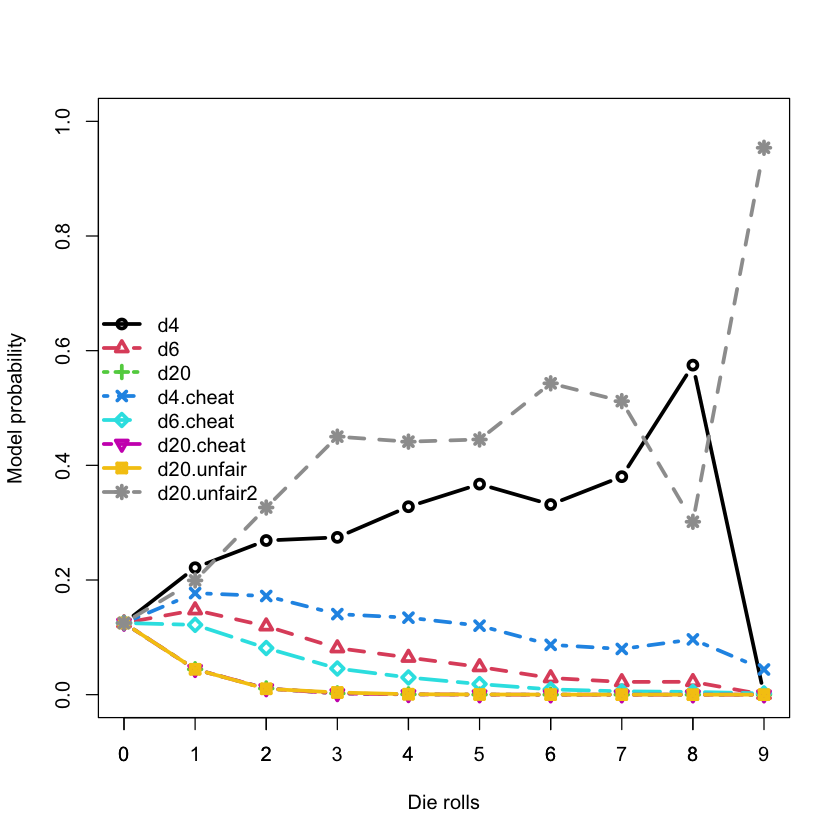

In [78]:
# Probability of observing x under a die model
likelihoods <- c("d4" = function(x) { return (ifelse(x >= 1 && x <= 4, 1 / 4, 0)) },
                 "d6" = function(x) { return (ifelse(x >= 1 && x <= 6, 1 / 6, 0)) }, 
                 "d20" = function(x) { return (ifelse(x >= 1 && x <= 20, 1 / 20, 0)) },
                 "d4.cheat" = function(x) { return (p.cheat * (1/20) + (1 - p.cheat) * (ifelse(x >= 1 && x <= 4, 1 / 4, 0))) },
                 "d6.cheat" = function(x) { return (p.cheat * (1/20) + (1 - p.cheat) * (ifelse(x >= 1 && x <= 6, 1 / 6, 0))) },
                 "d20.cheat" = function(x) { return (p.cheat * (1/20) + (1 - p.cheat) * (ifelse(x >= 1 && x <= 20, 1 / 20, 0))) },
                 "d20.unfair" = model_d20_unfair(),
                 #
                 # The alphas are the counts of each side plus 1:
                 #
                 "d20.unfair2" = model_d20_unfair(unfair+1))

model_probabilities <- matrix(
    nrow = length(observations)+1,
    ncol = length(names(likelihoods))
  )
  colnames(model_probabilities) <- names(likelihoods)
  rownames(model_probabilities) <- c("Prior", paste("Data",1:length(observations),":",as.character(observations))
)

current_prior <- uniform_prior()
model_probabilities[1,] <- current_prior
for (m in seq_along(observations)) {
    current_prior <- bayesian_update(observations[m], current_prior)
    model_probabilities[m+1, ] <- current_prior
}

print(round(model_probabilities, 6))

steps <- 0:(nrow(model_probabilities) - 1)

par(bg = "white")

cols <- seq_len(ncol(model_probabilities))
pchs <- seq_len(ncol(model_probabilities))
ltys <- seq_len(ncol(model_probabilities))

matplot(steps, model_probabilities, 
        type = "b", lw = 3, pch = pchs, lty = ltys, col = cols, ylim = c(0, 1), 
        xlab = "Die rolls", ylab = "Model probability")

axis(side = 1, at = steps)

legend("left", legend = colnames(model_probabilities), lw = 3, lty = ltys, pch = pchs, col = cols, bty = "n")

Yes, indeed. The more informed `d20.unfair2` proposal seems to be consistently more probable than most of our previous models, including the naive `d20.unfair` model, which started with equal and weak alpha values.

Under these circumstances, our DM thanks us and throws away the crooked die. We agree that we have played enough games for one night, and arrange to meet again for a proper journey into the fantastic world of Dungeons & Dragons.